# Data Augmentation on 6G Data (5G Proxies)

This notebook implements the experimental pipeline for the research project:

- **Tabular dataset:** `amf-performance.csv`, 8000 random samples, XGBoost downstream regressor.
- **Time-series dataset:** `python-web-server-performance.csv`, 13000 chronologically ordered rows, LSTM downstream regressor.
- **Tabular augmentation:** Gaussian Noise, SMOGN, CTGAN, TVAE.
- **Time-series augmentation:** Jittering, Time Warping, TS-Mixup, Frequency-domain augmentation.
- **Performance metrics:** RMSE, MAE, R².
- **Realism metrics:** KS statistic, SDMetrics Correlation Similarity, SDMetrics Boundary Adherence.


In [24]:
# 0. Imports and settings

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.stats import ks_2samp
from scipy.interpolate import CubicSpline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

try:
    import smogn
except Exception as e:
    smogn = None
    print("SMOGN is not available:", e)

try:
    from sdv.metadata import Metadata
    from sdv.single_table import CTGANSynthesizer, TVAESynthesizer
except Exception as e:
    Metadata = None
    CTGANSynthesizer = None
    TVAESynthesizer = None
    print("SDV is not available:", e)

try:
    from sdmetrics.column_pairs import CorrelationSimilarity
    from sdmetrics.single_column import BoundaryAdherence
except Exception as e:
    CorrelationSimilarity = None
    BoundaryAdherence = None
    print("SDMetrics is not available:", e)

# Seeding
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()
torch.manual_seed(RANDOM_STATE)

AMF_PATH = "./amf-performance.csv"
WEB_PATH = "./python-web-server-performance.csv"

TABULAR_FEATURES = ["ram_limit", "cpu_limit", "ram_usage", "cpu_usage", "n"]
TS_FEATURES = ["ram_limit", "cpu_limit", "ram_usage", "cpu_usage", "n", "c"]
TARGET = "lat100"

TABULAR_N_SAMPLES = 8000
TS_N_ROWS = 13000
WINDOW_SIZE = 10
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.15  # chronological validation split inside the time-series training portion
AUGMENT_RATIO = 0.50  # for CTGAN/TVAE and optional downsampling of synthetic data

## 1. Helper functions


In [5]:
def parse_ram_limit_to_mb(series):
    return pd.to_numeric(
        series.astype(str).str.replace("M", "", regex=False),
        errors="coerce"
    )


def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def print_df_info(name, df):
    print(f"{name} shape: {df.shape}")
    print(df.head())


def safe_numeric_df(df, columns):
    """Force selected columns to numeric, replace infinities, and drop missing rows. 
       It is used only for original dataset preprocessing.
    """
    out = df.copy()
    for col in columns:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return out


def coerce_numeric_df_no_drop(df, columns):
    """Force selected columns to numeric without dropping generated rows """
    out = df.copy()
    for col in columns:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan).reset_index(drop=True)
    return out


def validate_no_invalid_numeric(df, columns, context="dataframe"):
    """Raise an error if generated data contain NaN/inf after numeric conversion """
    invalid_mask = df[columns].isna().any(axis=1)
    if invalid_mask.any():
        n_invalid = int(invalid_mask.sum())
        raise ValueError(
            f"{context} contains {n_invalid} rows with NaN/inf after numeric conversion. "
        )


## 2. Dataset preprocessing

The latency percentile columns are removed from the feature sets because they are highly correlated with `lat100` and would introduce target leakage. For the time-series dataset, rows are kept in chronological order before creating sliding windows.

In [6]:
# Preprocessing functions

def preprocess_amf(path=AMF_PATH, n_samples=TABULAR_N_SAMPLES, random_state=RANDOM_STATE):
    df = pd.read_csv(path)
    df["ram_limit"] = parse_ram_limit_to_mb(df["ram_limit"])

    keep_cols = TABULAR_FEATURES + [TARGET]
    df = safe_numeric_df(df[keep_cols], keep_cols)

    if n_samples is not None and n_samples < len(df):
        df = df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    return df


def preprocess_web(path=WEB_PATH, n_rows=TS_N_ROWS):
    df = pd.read_csv(path)
    df = df.sort_values("time").reset_index(drop=True)
    df["ram_limit"] = parse_ram_limit_to_mb(df["ram_limit"])

    keep_cols = TS_FEATURES + [TARGET]
    df = safe_numeric_df(df[keep_cols], keep_cols)

    if n_rows is not None and n_rows < len(df):
        df = df.iloc[:n_rows].reset_index(drop=True)

    return df


tabular_df = preprocess_amf()
ts_df = preprocess_web()

print_df_info("AMF tabular dataset", tabular_df)
print_df_info("Python web server time-series dataset", ts_df)

AMF tabular dataset shape: (8000, 6)
   ram_limit  cpu_limit     ram_usage  cpu_usage    n    lat100
0       2560        2.0  1.073877e+09   1.025082  480  55714904
1       2560        3.0  5.080474e+08   0.555624  170   2513918
2       2304        2.5  9.968353e+08   0.100654   60    896495
3       3328        1.0  4.309770e+08   0.340005  100   1804976
4       1536        3.5  6.667674e+08   0.965387  290  14689717
Python web server time-series dataset shape: (13000, 7)
   ram_limit  cpu_limit   ram_usage  cpu_usage    n   c   lat100
0         75        0.5  43921408.0   0.064585  100   1   167000
1         75        0.5  43921408.0   0.000000  100  11  1284000
2         75        0.5  43921408.0   0.000000  100  21  2332000
3         75        0.5  43921408.0   0.000000  100  31  3941000
4         75        0.5  43921408.0   0.000000  100  41  6218000


## 3. Train/test split and scaling

For the tabular dataset, an 80/20 random split is used. For the time-series dataset, the raw rows are first split chronologically into training, validation, and test parts. Sliding windows are then created separately inside each split. This avoids overlap between training and test windows and keeps the validation set real and identical for all LSTM experiments.

In [7]:
# Tabular data splitting
X_tab = tabular_df[TABULAR_FEATURES].copy()
y_tab = tabular_df[TARGET].copy()

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab,
    y_tab,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Tabular train:", X_train_tab.shape, y_train_tab.shape)
print("Tabular test :", X_test_tab.shape, y_test_tab.shape)

Tabular train: (6400, 5) (6400,)
Tabular test : (1600, 5) (1600,)


In [8]:
#Time-series data splitting
def create_sequences(df, features, target, window_size):
    """Create sliding-window samples from a single chronological dataframe split."""
    X_raw = df[features].values.astype(float)
    y_raw = df[target].values.astype(float)

    X_seq, y_seq = [], []
    for i in range(len(df) - window_size):
        X_seq.append(X_raw[i:i + window_size])
        y_seq.append(y_raw[i + window_size])

    return np.array(X_seq), np.array(y_seq)


def chronological_row_train_val_test_split(df, test_size=TEST_SIZE, val_size=VALIDATION_SIZE):
    """Split raw chronological rows before creating windows. 
       The validation set is taken from the end of the training period.
    """
    test_start = int(len(df) * (1 - test_size))

    train_val_df = df.iloc[:test_start].reset_index(drop=True)
    test_df = df.iloc[test_start:].reset_index(drop=True)

    val_start = int(len(train_val_df) * (1 - val_size))
    train_df = train_val_df.iloc[:val_start].reset_index(drop=True)
    val_df = train_val_df.iloc[val_start:].reset_index(drop=True)

    return train_df, val_df, test_df


ts_train_df, ts_val_df, ts_test_df = chronological_row_train_val_test_split(ts_df)

X_train_ts_raw, y_train_ts_raw = create_sequences(ts_train_df, TS_FEATURES, TARGET, WINDOW_SIZE)
X_val_ts_raw, y_val_ts_raw = create_sequences(ts_val_df, TS_FEATURES, TARGET, WINDOW_SIZE)
X_test_ts_raw, y_test_ts_raw = create_sequences(ts_test_df, TS_FEATURES, TARGET, WINDOW_SIZE)

print("Time-series raw train rows:", ts_train_df.shape)
print("Time-series raw val rows  :", ts_val_df.shape)
print("Time-series raw test rows :", ts_test_df.shape)
print("Time-series train windows :", X_train_ts_raw.shape, y_train_ts_raw.shape)
print("Time-series val windows   :", X_val_ts_raw.shape, y_val_ts_raw.shape)
print("Time-series test windows  :", X_test_ts_raw.shape, y_test_ts_raw.shape)


Time-series raw train rows: (8840, 7)
Time-series raw val rows  : (1560, 7)
Time-series raw test rows : (2600, 7)
Time-series train windows : (8830, 10, 6) (8830,)
Time-series val windows   : (1550, 10, 6) (1550,)
Time-series test windows  : (2590, 10, 6) (2590,)


In [9]:
# Time-series scaling

def fit_transform_ts_scalers(X_train, X_val, X_test, y_train, y_val, y_test):
    n_features = X_train.shape[-1]

    x_scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, n_features)
    X_val_flat = X_val.reshape(-1, n_features)
    X_test_flat = X_test.reshape(-1, n_features)

    X_train_scaled = x_scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    X_val_scaled = x_scaler.transform(X_val_flat).reshape(X_val.shape)
    X_test_scaled = x_scaler.transform(X_test_flat).reshape(X_test.shape)

    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

    return (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled,
        y_train_scaled,
        y_val_scaled,
        y_test_scaled,
        x_scaler,
        y_scaler
    )


(
    X_train_ts,
    X_val_ts,
    X_test_ts,
    y_train_ts,
    y_val_ts,
    y_test_ts,
    x_scaler_ts,
    y_scaler_ts
) = fit_transform_ts_scalers(
    X_train_ts_raw,
    X_val_ts_raw,
    X_test_ts_raw,
    y_train_ts_raw,
    y_val_ts_raw,
    y_test_ts_raw
)


## 4. Realism metrics

The same realism framework is used for both data types:

- **KS statistic:** marginal distribution preservation, computed with SciPy's two-sample Kolmogorov-Smirnov statistic. Lower is better.
- **Correlation Similarity:** preservation of pairwise numerical relationships, computed directly with SDMetrics. Higher is better.
- **Boundary Adherence:** whether augmented values remain inside the observed real-data min/max range, computed directly with SDMetrics. Higher is better.

Realism is evaluated on the complete training dataset after augmentation: original training data plus generated samples. This is the dataset actually used by the downstream model. For time-series data, realism is computed over all timesteps in all training windows.

In [10]:
def _require_sdmetrics():
    if CorrelationSimilarity is None or BoundaryAdherence is None:
        raise ImportError(
            "SDMetrics is required for Correlation Similarity and Boundary Adherence. "
            "Install it with: pip install sdmetrics"
        )


def _prepare_metric_frame(df, columns):
    return df[columns].copy().replace([np.inf, -np.inf], np.nan)


def ks_statistic_mean(real_df, augmented_df, columns):
    """Mean Kolmogorov-Smirnov statistic over numerical columns."""
    real_clean = _prepare_metric_frame(real_df, columns)
    aug_clean = _prepare_metric_frame(augmented_df, columns)

    scores = []
    for col in columns:
        real_col = real_clean[col].dropna()
        aug_col = aug_clean[col].dropna()

        if len(real_col) == 0 or len(aug_col) == 0:
            scores.append(np.nan)
        elif real_col.nunique() <= 1 and aug_col.nunique() <= 1:
            scores.append(0.0)
        else:
            scores.append(ks_2samp(real_col, aug_col).statistic)

    return float(np.nanmean(scores))


def correlation_similarity_mean(real_df, augmented_df, columns, coefficient="Pearson"):
    """Mean pairwise Correlation Similarity over numerical columns """
    _require_sdmetrics()

    real_clean = _prepare_metric_frame(real_df, columns)
    aug_clean = _prepare_metric_frame(augmented_df, columns)

    scores = []
    for i, col_a in enumerate(columns):
        for col_b in columns[i + 1:]:
            pair_cols = [col_a, col_b]
            try:
                score = CorrelationSimilarity.compute(
                    real_data=real_clean[pair_cols],
                    synthetic_data=aug_clean[pair_cols],
                    coefficient=coefficient
                )
            except Exception:
                score = np.nan
            scores.append(score)

    return float(np.nanmean(scores))


def boundary_adherence_mean(real_df, augmented_df, columns):
    """Mean Boundary Adherence over numerical columns"""
    _require_sdmetrics()

    real_clean = _prepare_metric_frame(real_df, columns)
    aug_clean = _prepare_metric_frame(augmented_df, columns)

    scores = []
    for col in columns:
        try:
            score = BoundaryAdherence.compute(
                real_data=real_clean[col],
                synthetic_data=aug_clean[col]
            )
        except Exception:
            score = np.nan
        scores.append(score)

    return float(np.nanmean(scores))


def evaluate_realism(real_df, augmented_df, columns, method_name):
    return {
        "Method": method_name,
        "KS": ks_statistic_mean(real_df, augmented_df, columns),
        "Correlation_Similarity": correlation_similarity_mean(real_df, augmented_df, columns),
        "Boundary_Adherence": boundary_adherence_mean(real_df, augmented_df, columns)
    }


def make_tabular_frame(X, y, features, target=TARGET):
    out = X.copy().reset_index(drop=True)
    out[target] = np.asarray(y)
    return out


def timeseries_all_timesteps_frame(X_seq_raw, y_raw, features, target=TARGET):
    """Convert time-series windows into a timestep-level DataFrame. Every timestep in every window becomes one row. The window target is repeated for all timesteps in that window so the realism metrics are computed on the same augmented training set that is used by LSTM.
    """
    n_windows, window_size, n_features = X_seq_raw.shape
    out = pd.DataFrame(
        X_seq_raw.reshape(-1, n_features),
        columns=features
    )
    out[target] = np.repeat(np.asarray(y_raw), window_size)
    return out.reset_index(drop=True)


def inverse_transform_ts_windows(X_scaled, x_scaler):
    n_samples, window_size, n_features = X_scaled.shape
    X_flat = X_scaled.reshape(-1, n_features)
    X_raw = x_scaler.inverse_transform(X_flat).reshape(n_samples, window_size, n_features)
    return X_raw


def inverse_transform_y(y_scaled, y_scaler):
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).ravel()


## 5. Downstream model training functions

The AMF tabular dataset uses XGBoost. The time-series dataset uses an LSTM model.

In [11]:
# XGBoost
def train_evaluate_xgboost_tabular(X_train, y_train, X_test, y_test, method_name):
    """Fit scaler on the given training data, train XGBoost, and evaluate on test data."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    result = {"Method": method_name}
    result.update(regression_metrics(y_test, pred))
    return result, pred

In [12]:

# LSTM 
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(32, input_shape=input_shape),
        Dropout(0.10),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )
    return model


def train_evaluate_lstm(
    X_train,
    y_train_scaled,
    X_val,
    y_val_scaled,
    X_test,
    y_test_raw,
    y_scaler,
    method_name,
    epochs=100,
    batch_size=64,
    verbose=0
):
    
    model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_scaled,
        validation_data=(X_val, y_val_scaled),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop],
        verbose=verbose
    )

    pred_scaled = model.predict(X_test, verbose=0).ravel()
    pred_raw = inverse_transform_y(pred_scaled, y_scaler)

    result = {"Method": method_name}
    result.update(regression_metrics(y_test_raw, pred_raw))

    return result, pred_raw, history


## 6. Tabular augmentation methods

Each tabular augmentation function receives only the training set. It returns a new augmented training set which will also be used for realism evaluation.

In [13]:
# Tabular augmentation functions
def augment_gaussian_noise_tabular(X_train, y_train, noise_factor=0.05):
    train_df = make_tabular_frame(X_train, y_train, TABULAR_FEATURES)

    X_synth = X_train.copy().reset_index(drop=True)
    feature_stds = X_train.std(axis=0).replace(0, 1)
    noise = np.random.normal(0, noise_factor, size=X_synth.shape) * feature_stds.values
    X_synth = X_synth + noise

    synth_df = make_tabular_frame(X_synth, y_train.reset_index(drop=True), TABULAR_FEATURES)

    combined = pd.concat([train_df, synth_df], ignore_index=True)
    return combined[TABULAR_FEATURES], combined[TARGET], synth_df


def augment_smogn_tabular(X_train, y_train):
    if smogn is None:
        raise ImportError("smogn is not installed")

    train_df = make_tabular_frame(X_train, y_train, TABULAR_FEATURES).reset_index(drop=True)

    smogn_df = smogn.smoter(
        data=train_df,
        y=TARGET
    ).reset_index(drop=True)

    # SMOGN returns a full resampled training dataset, not a synthetic-only subset.
    return smogn_df[TABULAR_FEATURES], smogn_df[TARGET], smogn_df


def build_sdv_metadata(train_df):
    metadata = Metadata.detect_from_dataframe(train_df)
    return metadata


def augment_sdv_tabular(X_train, y_train, synthesizer_name="CTGAN", augment_ratio=AUGMENT_RATIO, epochs=300):
    if Metadata is None:
        raise ImportError("sdv is not installed")

    train_df = make_tabular_frame(X_train, y_train, TABULAR_FEATURES).reset_index(drop=True)
    metadata = build_sdv_metadata(train_df)

    if synthesizer_name.upper() == "CTGAN":
        synthesizer = CTGANSynthesizer(metadata, epochs=epochs, verbose=False)
    elif synthesizer_name.upper() == "TVAE":
        synthesizer = TVAESynthesizer(metadata, epochs=epochs)
    else:
        raise ValueError("synthesizer_name must be 'CTGAN' or 'TVAE'")

    synthesizer.fit(train_df)
    n_synth = int(len(train_df) * augment_ratio)
    synthesizer.reset_sampling()
    synth_df = synthesizer.sample(num_rows=n_synth)

    # Convert generated columns to numeric, but do not drop or repair rows.
    synth_df = coerce_numeric_df_no_drop(
        synth_df[TABULAR_FEATURES + [TARGET]],
        TABULAR_FEATURES + [TARGET]
    )
    validate_no_invalid_numeric(
        synth_df,
        TABULAR_FEATURES + [TARGET],
        context=f"{synthesizer_name} synthetic data"
    )

    combined = pd.concat([train_df, synth_df], ignore_index=True)
    return combined[TABULAR_FEATURES], combined[TARGET], synth_df


## 7. Run tabular experiments

In [14]:
tabular_performance = []
tabular_realism = []
tabular_predictions = {}

real_tab_train_df = make_tabular_frame(X_train_tab, y_train_tab, TABULAR_FEATURES)
realism_columns_tab = TABULAR_FEATURES + [TARGET]

# store baseline and full augmented training datasets for detailed Boundary Adherence diagnostics.
tabular_diagnostic_datasets = {"Baseline": real_tab_train_df.copy()}

# baseline
result, pred = train_evaluate_xgboost_tabular(
    X_train_tab, y_train_tab, X_test_tab, y_test_tab, "Baseline"
)
tabular_performance.append(result)
tabular_predictions["Baseline"] = pred

tabular_realism.append({"Method": "Baseline", "KS": 0.0, "Correlation_Similarity": 1.0, "Boundary_Adherence": 1.0})

# Gaussian Noise
X_aug, y_aug, synth_df = augment_gaussian_noise_tabular(X_train_tab, y_train_tab)
result, pred = train_evaluate_xgboost_tabular(X_aug, y_aug, X_test_tab, y_test_tab, "Gaussian Noise")
tabular_performance.append(result)
tabular_predictions["Gaussian Noise"] = pred
aug_train_df = make_tabular_frame(X_aug, y_aug, TABULAR_FEATURES)
tabular_realism.append(evaluate_realism(real_tab_train_df, aug_train_df, realism_columns_tab, "Gaussian Noise"))
tabular_diagnostic_datasets["Gaussian Noise"] = aug_train_df.copy()

# SMOGN
try:
    X_aug, y_aug, synth_df = augment_smogn_tabular(X_train_tab, y_train_tab)
    result, pred = train_evaluate_xgboost_tabular(X_aug, y_aug, X_test_tab, y_test_tab, "SMOGN")
    tabular_performance.append(result)
    tabular_predictions["SMOGN"] = pred
    aug_train_df = make_tabular_frame(X_aug, y_aug, TABULAR_FEATURES)
    tabular_realism.append(evaluate_realism(real_tab_train_df, aug_train_df, realism_columns_tab, "SMOGN"))
    tabular_diagnostic_datasets["SMOGN"] = aug_train_df.copy()
except Exception as e:
    print("SMOGN skipped because of error:", e)

# CTGAN
try:
    X_aug, y_aug, synth_df = augment_sdv_tabular(X_train_tab, y_train_tab, "CTGAN", epochs=500)
    result, pred = train_evaluate_xgboost_tabular(X_aug, y_aug, X_test_tab, y_test_tab, "CTGAN")
    tabular_performance.append(result)
    tabular_predictions["CTGAN"] = pred
    aug_train_df = make_tabular_frame(X_aug, y_aug, TABULAR_FEATURES)
    tabular_realism.append(evaluate_realism(real_tab_train_df, aug_train_df, realism_columns_tab, "CTGAN"))
    tabular_diagnostic_datasets["CTGAN"] = aug_train_df.copy()
except Exception as e:
    print("CTGAN skipped because of error:", e)

# TVAE
try:
    X_aug, y_aug, synth_df = augment_sdv_tabular(X_train_tab, y_train_tab, "TVAE", epochs=500)
    result, pred = train_evaluate_xgboost_tabular(X_aug, y_aug, X_test_tab, y_test_tab, "TVAE")
    tabular_performance.append(result)
    tabular_predictions["TVAE"] = pred
    aug_train_df = make_tabular_frame(X_aug, y_aug, TABULAR_FEATURES)
    tabular_realism.append(evaluate_realism(real_tab_train_df, aug_train_df, realism_columns_tab, "TVAE"))
    tabular_diagnostic_datasets["TVAE"] = aug_train_df.copy()
except Exception as e:
    print("TVAE skipped because of error:", e)


tabular_performance_df = pd.DataFrame(tabular_performance)
tabular_realism_df = pd.DataFrame(tabular_realism)

print("Tabular performance")
display(tabular_performance_df)

print("Tabular realism")
display(tabular_realism_df)


r_index: 100%|##########| 558/558 [00:00<00:00, 1973.50it/s]


Tabular performance


,Method,RMSE,MAE,R2
0,Baseline,2.523619e+06,9.479656e+05,0.983792
1,Gaussian Noise,2.728919e+06,9.734254e+05,0.981048
2,SMOGN,2.866206e+06,1.072793e+06,0.979093
3,CTGAN,2.972432e+06,1.313823e+06,0.977514
4,TVAE,2.871573e+06,1.246597e+06,0.979014


Tabular realism


,Method,KS,Correlation_Similarity,Boundary_Adherence
0,Baseline,0.000000,1.000000,1.000000
1,Gaussian Noise,0.017292,0.999813,0.981068
2,SMOGN,0.244668,0.950565,1.000000
3,CTGAN,0.028056,0.977924,1.000000
4,TVAE,0.039201,0.989527,1.000000


## 8. Time-series augmentation methods

These augmentations operate on 3D LSTM inputs with shape `(samples, timesteps, features)`. They are applied only to the scaled training windows.

In [15]:
# Time-series augmentation functions
def jitter_ts(X, sigma=0.03):
    return X + np.random.normal(0, sigma, size=X.shape)

def time_warp_ts(X, sigma=0.20, knot=4):
    X = np.asarray(X)
    if X.ndim != 3:
        raise ValueError("time_warp_ts expects X with shape (n_samples, window_size, n_features).")

    n_samples, window_size, n_features = X.shape
    orig_steps = np.arange(window_size)

    random_warps = np.random.normal(
        loc=1.0,
        scale=sigma,
        size=(n_samples, knot + 2, n_features)
    )

    warp_steps = np.tile(
        np.linspace(0, window_size - 1, num=knot + 2),
        (n_features, 1)
    ).T

    X_aug = np.zeros_like(X)

    for i, pat in enumerate(X):
        for dim in range(n_features):
            time_warp = CubicSpline(
                warp_steps[:, dim],
                warp_steps[:, dim] * random_warps[i, :, dim]
            )(orig_steps)

            scale = (window_size - 1) / time_warp[-1]
            X_aug[i, :, dim] = np.interp(
                orig_steps,
                np.clip(scale * time_warp, 0, window_size - 1),
                pat[:, dim]
            ).T

    return X_aug


def ts_mixup(X, y, alpha=0.2):
    n_samples = len(X)
    indices_1 = np.random.randint(0, n_samples, size=n_samples)
    indices_2 = np.random.randint(0, n_samples, size=n_samples)
    lam = np.random.beta(alpha, alpha, size=n_samples)

    X_mix = lam[:, None, None] * X[indices_1] + (1 - lam[:, None, None]) * X[indices_2]
    y_mix = lam * y[indices_1] + (1 - lam) * y[indices_2]

    return X_mix, y_mix


def frequency_augment_ts(X, noise_factor=0.05):
    X_aug = np.zeros_like(X)

    for i in range(X.shape[0]):
        for f in range(X.shape[2]):
            signal = X[i, :, f]
            fft_signal = np.fft.rfft(signal)

            # Perturb spectral coefficients slightly.
            complex_noise = (
                np.random.normal(0, noise_factor, len(fft_signal))
                + 1j * np.random.normal(0, noise_factor, len(fft_signal))
            )
            fft_aug = fft_signal + complex_noise
            X_aug[i, :, f] = np.fft.irfft(fft_aug, n=len(signal))

    return X_aug


def combine_ts_original_and_augmented(X_train, y_train, X_synth, y_synth):
    return (
        np.concatenate([X_train, X_synth], axis=0),
        np.concatenate([y_train, y_synth], axis=0)
    )

## 9. Run time-series LSTM experiments

In [16]:
timeseries_performance = []
timeseries_realism = []
timeseries_predictions = {}
timeseries_histories = {}

real_ts_train_df = timeseries_all_timesteps_frame(X_train_ts_raw, y_train_ts_raw, TS_FEATURES)
realism_columns_ts = TS_FEATURES + [TARGET]

# again store baseline and full augmented training datasets for detailed Boundary Adherence diagnostics.
timeseries_diagnostic_datasets = {"Baseline LSTM": real_ts_train_df.copy()}

# baseline LSTM
result, pred, history = train_evaluate_lstm(
    X_train_ts,
    y_train_ts,
    X_val_ts,
    y_val_ts,
    X_test_ts,
    y_test_ts_raw,
    y_scaler_ts,
    "Baseline LSTM"
)
timeseries_performance.append(result)
timeseries_predictions["Baseline LSTM"] = pred
timeseries_histories["Baseline LSTM"] = history
timeseries_realism.append({"Method": "Baseline LSTM", "KS": 0.0, "Correlation_Similarity": 1.0, "Boundary_Adherence": 1.0})


def make_ts_augmented_diagnostic_frame(X_aug_scaled, y_aug_scaled):
    """Convert a scaled full augmented training set back to raw-unit timestep-level form."""
    X_aug_raw = inverse_transform_ts_windows(X_aug_scaled, x_scaler_ts)
    y_aug_raw = inverse_transform_y(y_aug_scaled, y_scaler_ts)
    return timeseries_all_timesteps_frame(X_aug_raw, y_aug_raw, TS_FEATURES)


def evaluate_ts_augmented_realism(method_name, X_aug_scaled, y_aug_scaled):
    aug_df = make_ts_augmented_diagnostic_frame(X_aug_scaled, y_aug_scaled)
    timeseries_diagnostic_datasets[method_name] = aug_df.copy()
    return evaluate_realism(real_ts_train_df, aug_df, realism_columns_ts, method_name)


# Jittering
X_synth = jitter_ts(X_train_ts, sigma=0.03)
y_synth = y_train_ts.copy()
X_comb, y_comb = combine_ts_original_and_augmented(X_train_ts, y_train_ts, X_synth, y_synth)
result, pred, history = train_evaluate_lstm(X_comb, y_comb, X_val_ts, y_val_ts, X_test_ts, y_test_ts_raw, y_scaler_ts, "Jittering")
timeseries_performance.append(result)
timeseries_predictions["Jittering"] = pred
timeseries_histories["Jittering"] = history
timeseries_realism.append(evaluate_ts_augmented_realism("Jittering", X_comb, y_comb))

# Time Warping
X_synth = time_warp_ts(X_train_ts, sigma=0.20)
y_synth = y_train_ts.copy()
X_comb, y_comb = combine_ts_original_and_augmented(X_train_ts, y_train_ts, X_synth, y_synth)
result, pred, history = train_evaluate_lstm(X_comb, y_comb, X_val_ts, y_val_ts, X_test_ts, y_test_ts_raw, y_scaler_ts, "Time Warping")
timeseries_performance.append(result)
timeseries_predictions["Time Warping"] = pred
timeseries_histories["Time Warping"] = history
timeseries_realism.append(evaluate_ts_augmented_realism("Time Warping", X_comb, y_comb))

# TS-Mixup
X_synth, y_synth = ts_mixup(X_train_ts, y_train_ts, alpha=0.2)
X_comb, y_comb = combine_ts_original_and_augmented(X_train_ts, y_train_ts, X_synth, y_synth)
result, pred, history = train_evaluate_lstm(X_comb, y_comb, X_val_ts, y_val_ts, X_test_ts, y_test_ts_raw, y_scaler_ts, "TS-Mixup")
timeseries_performance.append(result)
timeseries_predictions["TS-Mixup"] = pred
timeseries_histories["TS-Mixup"] = history
timeseries_realism.append(evaluate_ts_augmented_realism("TS-Mixup", X_comb, y_comb))

# Frequency-domain augmentation
X_synth = frequency_augment_ts(X_train_ts, noise_factor=0.05)
y_synth = y_train_ts.copy()
X_comb, y_comb = combine_ts_original_and_augmented(X_train_ts, y_train_ts, X_synth, y_synth)
result, pred, history = train_evaluate_lstm(X_comb, y_comb, X_val_ts, y_val_ts, X_test_ts, y_test_ts_raw, y_scaler_ts, "Frequency-domain")
timeseries_performance.append(result)
timeseries_predictions["Frequency-domain"] = pred
timeseries_histories["Frequency-domain"] = history
timeseries_realism.append(evaluate_ts_augmented_realism("Frequency-domain", X_comb, y_comb))


timeseries_performance_df = pd.DataFrame(timeseries_performance)
timeseries_realism_df = pd.DataFrame(timeseries_realism)

print("Time-series performance")
display(timeseries_performance_df)

print("Time-series realism")
display(timeseries_realism_df)


Time-series performance


,Method,RMSE,MAE,R2
0,Baseline LSTM,6.310240e+07,3.453243e+07,-21.997886
1,Jittering,7.595157e+07,4.380219e+07,-32.317287
2,Time Warping,7.335879e+07,4.495415e+07,-30.081398
3,TS-Mixup,1.535801e+08,1.094081e+08,-135.227833
4,Frequency-domain,3.158871e+07,1.951103e+07,-4.763150


Time-series realism


,Method,KS,Correlation_Similarity,Boundary_Adherence
0,Baseline LSTM,0.000000,1.000000,1.000000
1,Jittering,0.055699,0.999943,0.942668
2,Time Warping,0.060084,0.997319,0.960404
3,TS-Mixup,0.071926,0.998728,0.970332
4,Frequency-domain,0.055270,0.999967,0.943453


## 10. Tables and plots

These plots compare how each augmentation method affects regression performance and realism.

In [17]:
# helper function for plotting
def plot_metric_bars(df, metrics, title_prefix):
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.bar(df["Method"], df[metric])
        plt.title(f"{title_prefix}: {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()


def add_delta_vs_baseline(df, baseline_name):
    out = df.copy()
    baseline = out[out["Method"] == baseline_name].iloc[0]
    for metric in ["RMSE", "MAE", "R2"]:
        out[f"Delta_{metric}_vs_Baseline"] = out[metric] - baseline[metric]
    return out


def plot_actual_vs_predicted(y_true, predictions_dict, title, max_points=300):
    plt.figure(figsize=(10, 4))
    n = min(len(y_true), max_points)
    plt.plot(np.asarray(y_true)[:n], label="Actual", linewidth=2)
    for method, pred in predictions_dict.items():
        plt.plot(np.asarray(pred)[:n], label=method, alpha=0.8)
    plt.title(title)
    plt.xlabel("Test sample")
    plt.ylabel(TARGET)
    plt.legend()
    plt.tight_layout()
    plt.show()

Tabular performance summary


,Method,RMSE,MAE,R2,Delta_RMSE_vs_Baseline,Delta_MAE_vs_Baseline,Delta_R2_vs_Baseline
0,Baseline,2.523619e+06,9.479656e+05,0.983792,0.000000,0.000000,0.000000
1,Gaussian Noise,2.728919e+06,9.734254e+05,0.981048,205300.488209,25459.787546,-0.002744
2,SMOGN,2.866206e+06,1.072793e+06,0.979093,342587.051539,124827.914583,-0.004699
3,CTGAN,2.972432e+06,1.313823e+06,0.977514,448813.208170,365857.295791,-0.006278
4,TVAE,2.871573e+06,1.246597e+06,0.979014,347954.123277,298631.173687,-0.004778


Tabular realism summary


,Method,KS,Correlation_Similarity,Boundary_Adherence
0,Baseline,0.000000,1.000000,1.000000
1,Gaussian Noise,0.017292,0.999813,0.981068
2,SMOGN,0.244668,0.950565,1.000000
3,CTGAN,0.028056,0.977924,1.000000
4,TVAE,0.039201,0.989527,1.000000


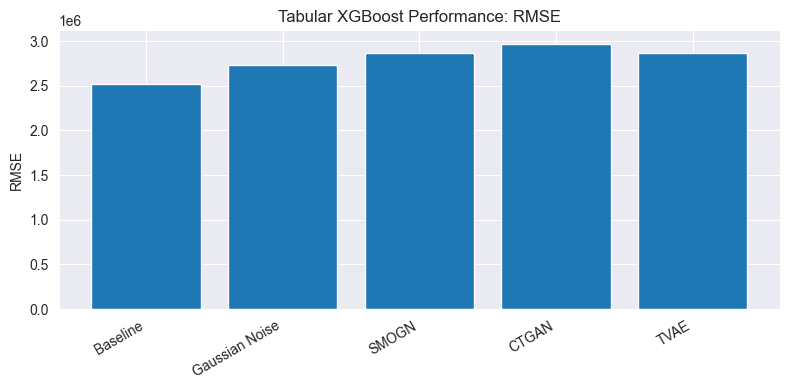

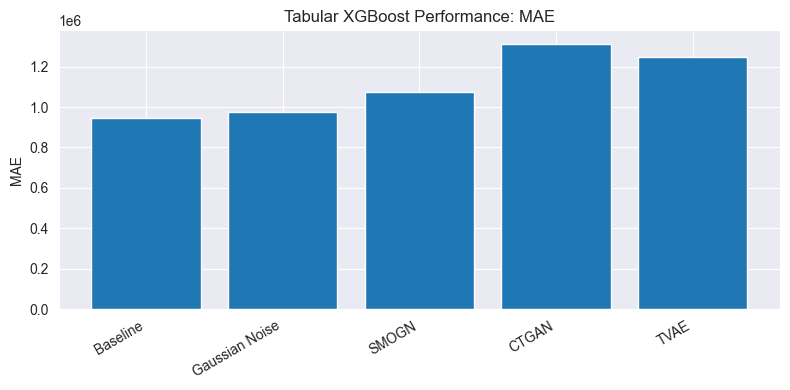

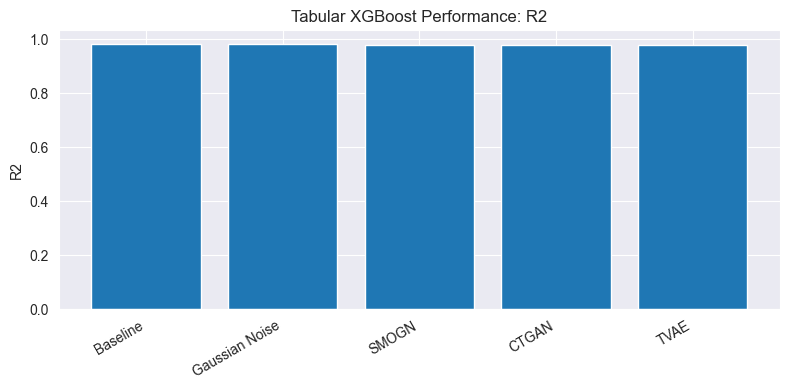

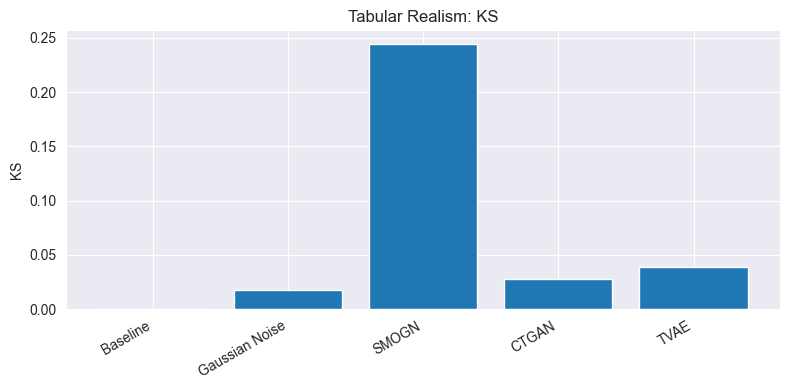

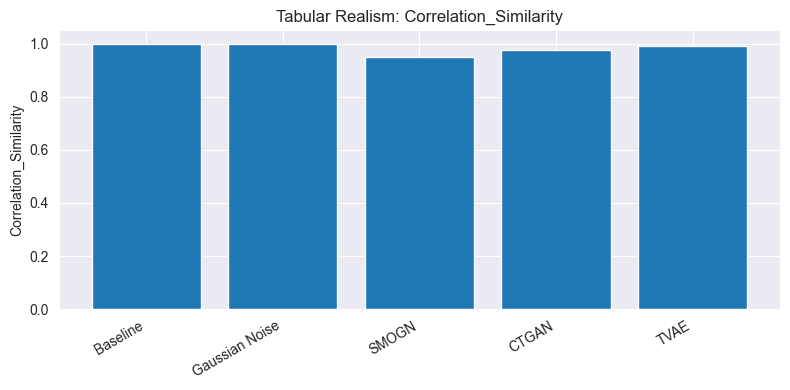

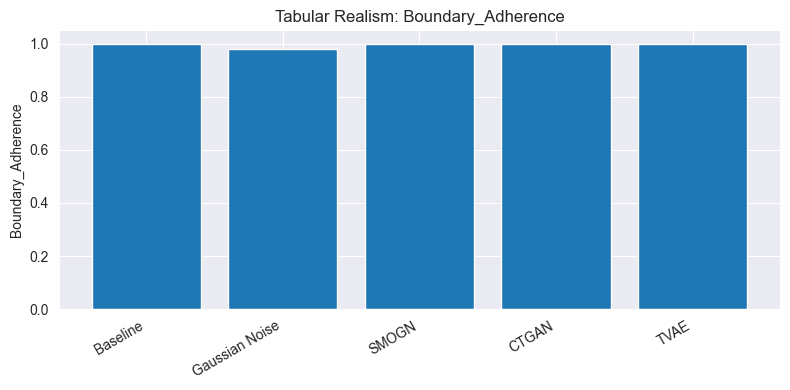

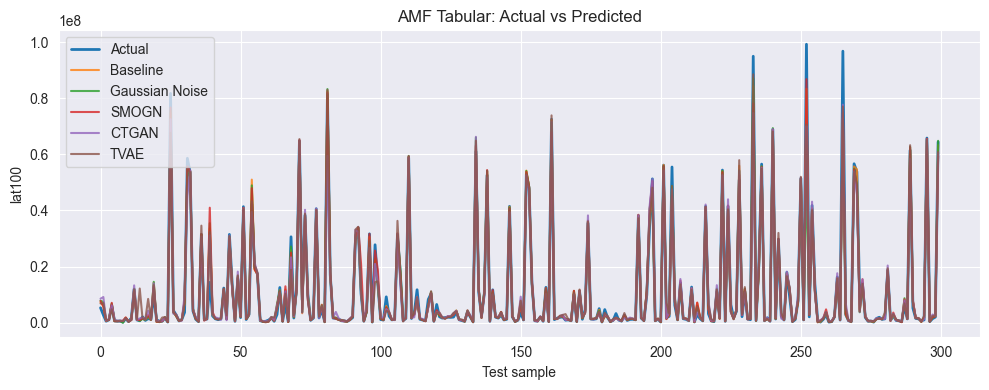

In [18]:
# tables and plots for tabular results
tabular_summary = add_delta_vs_baseline(tabular_performance_df, "Baseline")
print("Tabular performance summary")
display(tabular_summary)

print("Tabular realism summary")
display(tabular_realism_df)

plot_metric_bars(tabular_performance_df, ["RMSE", "MAE", "R2"], "Tabular XGBoost Performance")
plot_metric_bars(tabular_realism_df, ["KS", "Correlation_Similarity", "Boundary_Adherence"], "Tabular Realism")

plot_actual_vs_predicted(y_test_tab.values, tabular_predictions, "AMF Tabular: Actual vs Predicted")

Time-series performance summary


,Method,RMSE,MAE,R2,Delta_RMSE_vs_Baseline,Delta_MAE_vs_Baseline,Delta_R2_vs_Baseline
0,Baseline LSTM,6.310240e+07,3.453243e+07,-21.997886,0.000000e+00,0.000000e+00,0.000000
1,Jittering,7.595157e+07,4.380219e+07,-32.317287,1.284917e+07,9.269755e+06,-10.319401
2,Time Warping,7.335879e+07,4.495415e+07,-30.081398,1.025640e+07,1.042172e+07,-8.083512
3,TS-Mixup,1.535801e+08,1.094081e+08,-135.227833,9.047766e+07,7.487566e+07,-113.229947
4,Frequency-domain,3.158871e+07,1.951103e+07,-4.763150,-3.151369e+07,-1.502140e+07,17.234736


Time-series realism summary


,Method,KS,Correlation_Similarity,Boundary_Adherence
0,Baseline LSTM,0.000000,1.000000,1.000000
1,Jittering,0.055699,0.999943,0.942668
2,Time Warping,0.060084,0.997319,0.960404
3,TS-Mixup,0.071926,0.998728,0.970332
4,Frequency-domain,0.055270,0.999967,0.943453


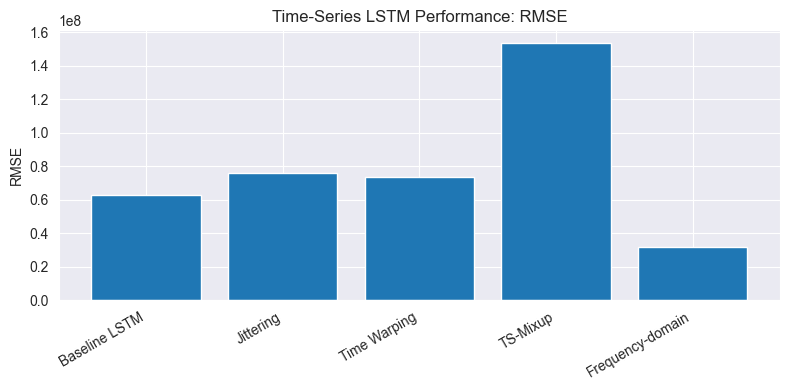

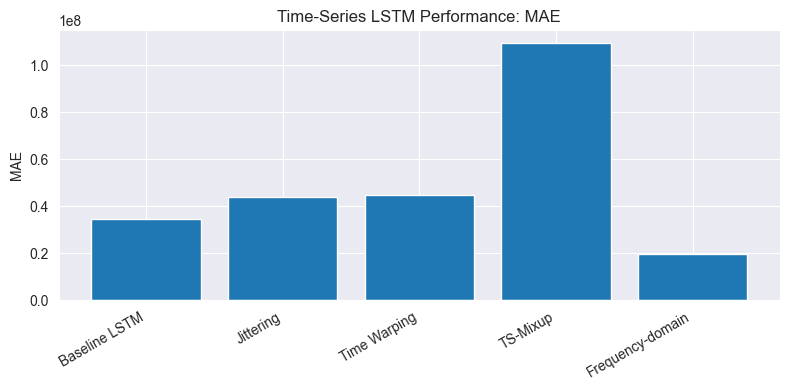

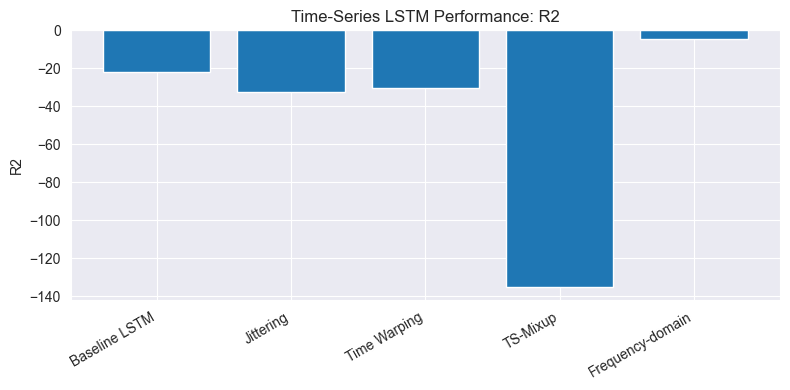

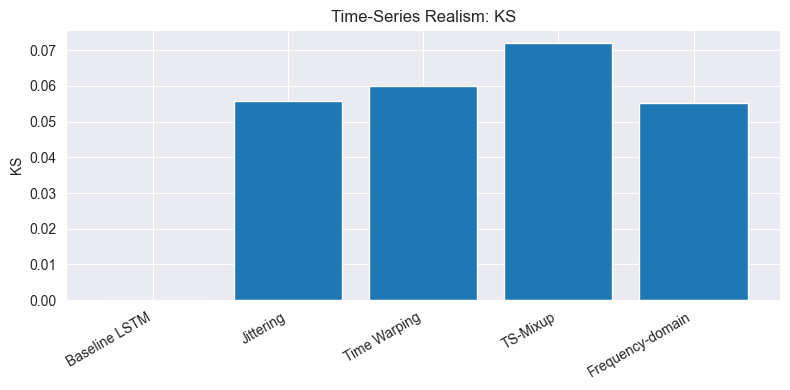

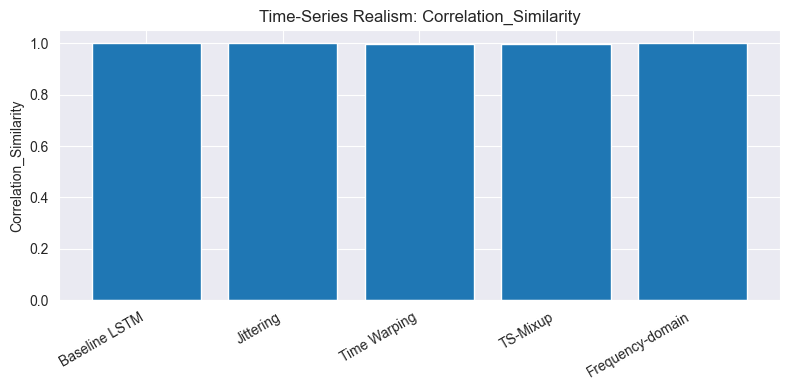

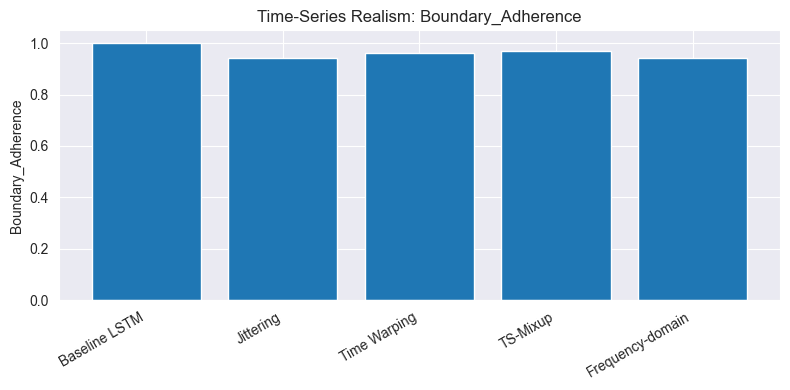

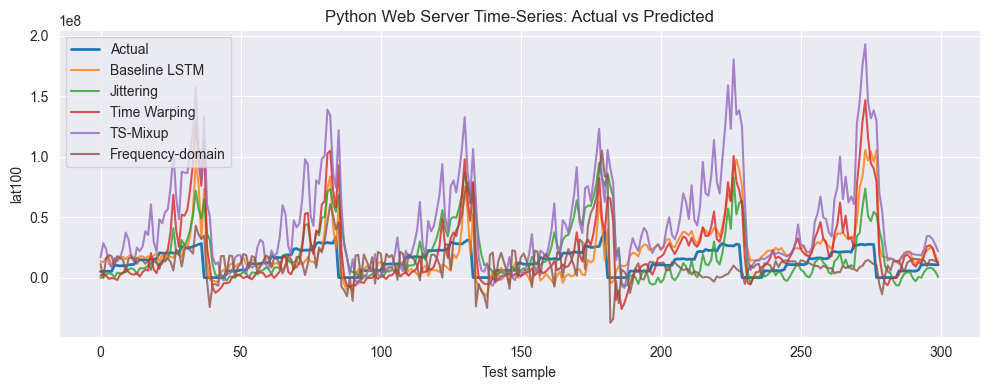

In [19]:
# tables and plots for time-series results
ts_summary = add_delta_vs_baseline(timeseries_performance_df, "Baseline LSTM")
print("Time-series performance summary")
display(ts_summary)

print("Time-series realism summary")
display(timeseries_realism_df)

plot_metric_bars(timeseries_performance_df, ["RMSE", "MAE", "R2"], "Time-Series LSTM Performance")
plot_metric_bars(timeseries_realism_df, ["KS", "Correlation_Similarity", "Boundary_Adherence"], "Time-Series Realism")

plot_actual_vs_predicted(y_test_ts_raw, timeseries_predictions, "Python Web Server Time-Series: Actual vs Predicted")

## Boundary adherence diagnostics

This section breaks down Boundary Adherence by individual column, for both the baseline and each full augmented training dataset. This identifies which features or targets produce values outside the observed real-data min/max range.

Tabular overall Boundary Adherence


,Method,Boundary_Adherence
0,Baseline,1.000000
1,Gaussian Noise,0.981068
2,SMOGN,1.000000
3,CTGAN,1.000000
4,TVAE,1.000000


Tabular column-level Boundary Adherence summary


,Method,Column,Real_Min,Real_Max,Augmented_Count,Out_Of_Bounds_Count,Out_Of_Bounds_Rate,Boundary_Adherence
0,Baseline,ram_limit,256.0,4.096000e+03,6400,0,0.000000,1.000000
1,Baseline,cpu_limit,0.5,4.000000e+00,6400,0,0.000000,1.000000
2,Baseline,ram_usage,98910208.0,1.927434e+09,6400,0,0.000000,1.000000
3,Baseline,cpu_usage,0.0,1.445758e+00,6400,0,0.000000,1.000000
4,Baseline,n,10.0,5.600000e+02,6400,0,0.000000,1.000000
5,Baseline,lat100,170634.0,9.978410e+07,6400,0,0.000000,1.000000
18,CTGAN,ram_limit,256.0,4.096000e+03,9600,0,0.000000,1.000000
19,CTGAN,cpu_limit,0.5,4.000000e+00,9600,0,0.000000,1.000000
20,CTGAN,ram_usage,98910208.0,1.927434e+09,9600,0,0.000000,1.000000
21,CTGAN,cpu_usage,0.0,1.445758e+00,9600,0,0.000000,1.000000


Example tabular rows outside real-data boundaries


,ram_limit,cpu_limit,ram_usage,cpu_usage,n,lat100,Method,Out_Of_Bounds_Columns
0,2022.761864,0.473717,5.814194e+08,0.466493,208.169586,30495986,Gaussian Noise,cpu_limit
1,1836.761535,4.004912,5.643081e+08,0.611902,186.368184,6985578,Gaussian Noise,cpu_limit
2,4101.286929,2.554665,1.154770e+09,1.043567,507.310712,66161668,Gaussian Noise,ram_limit
3,3479.502027,0.498504,1.832070e+09,0.369248,68.680685,4232015,Gaussian Noise,cpu_limit
4,555.080297,0.448679,5.607870e+08,0.475313,234.024981,38977814,Gaussian Noise,cpu_limit
5,4215.294145,1.444099,4.670734e+08,0.008599,36.546893,693657,Gaussian Noise,ram_limit
6,1999.556260,0.453960,2.850030e+08,0.141446,41.897694,1746476,Gaussian Noise,cpu_limit
7,3815.682402,2.548331,7.123462e+08,-0.005746,31.187768,453538,Gaussian Noise,cpu_usage
8,1555.485415,4.031648,7.972363e+08,0.129162,50.551203,1148718,Gaussian Noise,cpu_limit
9,1662.058347,3.894622,5.863330e+08,-0.022073,16.763238,341409,Gaussian Noise,cpu_usage


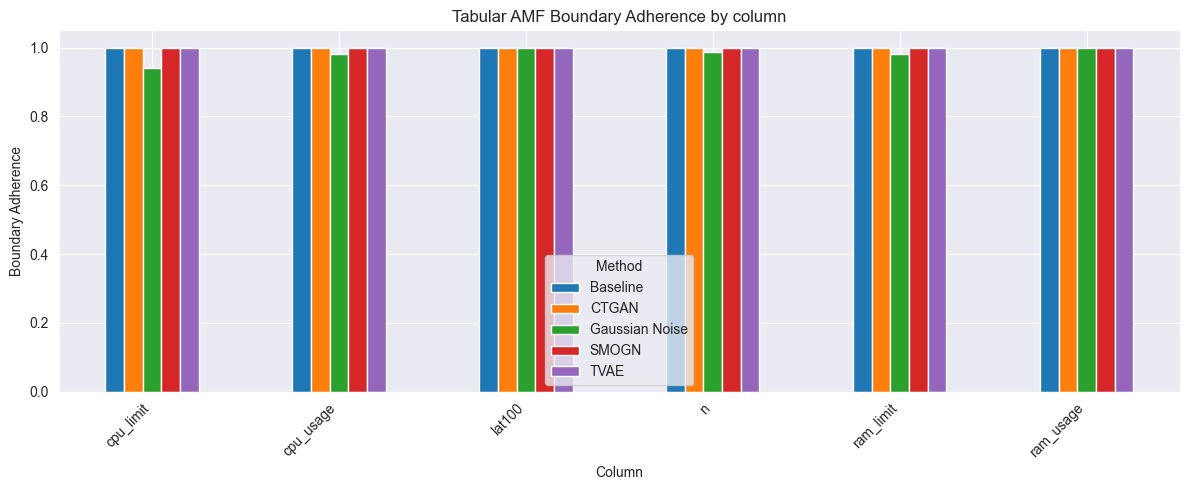

Time-series overall Boundary Adherence


,Method,Boundary_Adherence
0,Baseline LSTM,1.000000
1,Jittering,0.942668
2,Time Warping,0.960404
3,TS-Mixup,0.970332
4,Frequency-domain,0.943453


Time-series column-level Boundary Adherence summary


,Method,Column,Real_Min,Real_Max,Augmented_Count,Out_Of_Bounds_Count,Out_Of_Bounds_Rate,Boundary_Adherence
0,Baseline LSTM,ram_limit,63.0,1.024000e+03,88300,0,0.000000,1.000000
1,Baseline LSTM,cpu_limit,0.1,2.000000e+00,88300,0,0.000000,1.000000
2,Baseline LSTM,ram_usage,0.0,1.371832e+08,88300,0,0.000000,1.000000
3,Baseline LSTM,cpu_usage,0.0,1.999238e+00,88300,0,0.000000,1.000000
4,Baseline LSTM,n,100.0,1.000000e+03,88300,0,0.000000,1.000000
5,Baseline LSTM,c,1.0,1.010000e+02,88300,0,0.000000,1.000000
6,Baseline LSTM,lat100,55000.0,1.960394e+09,88300,0,0.000000,1.000000
29,Frequency-domain,cpu_limit,0.1,2.000000e+00,176600,45857,0.259666,0.740334
32,Frequency-domain,n,100.0,1.000000e+03,176600,9907,0.056099,0.943901
33,Frequency-domain,c,1.0,1.010000e+02,176600,7448,0.042174,0.957826


Example time-series rows/windows outside real-data boundaries


,ram_limit,cpu_limit,ram_usage,cpu_usage,n,c,lat100,Method,Out_Of_Bounds_Columns
0,128.0,0.1,35856384.0,0.024597,100.0,1.0,1592000.0,Jittering,cpu_limit
1,128.0,0.1,35856384.0,0.024597,100.0,1.0,10393000.0,Jittering,cpu_limit
2,128.0,0.1,65650688.0,0.035358,100.0,1.0,10393000.0,Jittering,cpu_limit
3,128.0,0.1,35856384.0,0.024597,100.0,1.0,13194000.0,Jittering,cpu_limit
4,128.0,0.1,65650688.0,0.035358,100.0,1.0,13194000.0,Jittering,cpu_limit
5,128.0,0.1,41144320.0,0.040710,100.0,11.0,13194000.0,Jittering,cpu_limit
6,128.0,0.1,35856384.0,0.024597,100.0,1.0,19299000.0,Jittering,cpu_limit
7,128.0,0.1,65650688.0,0.035358,100.0,1.0,19299000.0,Jittering,cpu_limit
8,128.0,0.1,41144320.0,0.040710,100.0,11.0,19299000.0,Jittering,cpu_limit
9,128.0,0.1,50483200.0,0.051704,100.0,11.0,19299000.0,Jittering,cpu_limit


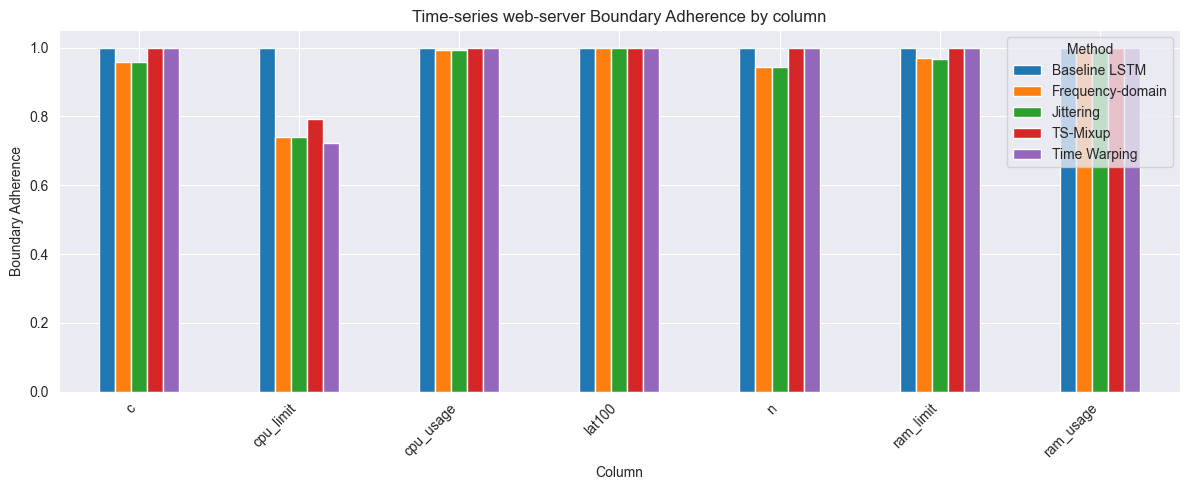

In [20]:
def boundary_adherence_diagnostics(real_df, augmented_df, columns, method_name):
    _require_sdmetrics()

    real_clean = _prepare_metric_frame(real_df, columns)
    aug_clean = _prepare_metric_frame(augmented_df, columns)
    rows = []

    for col in columns:
        real_col = real_clean[col]
        aug_col = aug_clean[col]
        valid_aug = aug_col.notna()
        valid_count = int(valid_aug.sum())

        real_nonmissing = real_col.dropna()
        if len(real_nonmissing) == 0:
            lower = np.nan
            upper = np.nan
            adherence = np.nan
            out_of_bounds_count = 0
            out_of_bounds_rate = np.nan
        else:
            lower = real_nonmissing.min()
            upper = real_nonmissing.max()
            adherence = BoundaryAdherence.compute(
                real_data=real_col,
                synthetic_data=aug_col
            )
            in_bounds = aug_col.between(lower, upper, inclusive="both")
            out_of_bounds_count = int((~in_bounds[valid_aug]).sum())
            out_of_bounds_rate = float(out_of_bounds_count / valid_count) if valid_count > 0 else np.nan

        rows.append({
            "Method": method_name,
            "Column": col,
            "Real_Min": lower,
            "Real_Max": upper,
            "Augmented_Count": valid_count,
            "Out_Of_Bounds_Count": out_of_bounds_count,
            "Out_Of_Bounds_Rate": out_of_bounds_rate,
            "Boundary_Adherence": adherence
        })

    return pd.DataFrame(rows)


def boundary_out_of_bounds_rows(real_df, augmented_df, columns, method_name):
    """Return augmented rows that violate at least one original data boundary."""
    real_clean = _prepare_metric_frame(real_df, columns)
    aug_clean = _prepare_metric_frame(augmented_df, columns)
    violation_mask = pd.Series(False, index=augmented_df.index)
    violated_columns = pd.Series("", index=augmented_df.index, dtype=object)

    for col in columns:
        real_col = real_clean[col].dropna()
        aug_col = aug_clean[col]

        if len(real_col) == 0:
            continue

        lower = real_col.min()
        upper = real_col.max()
        col_violation = aug_col.notna() & ~aug_col.between(lower, upper, inclusive="both")
        violation_mask |= col_violation
        violated_columns.loc[col_violation] = violated_columns.loc[col_violation].apply(
            lambda existing: f"{existing}, {col}" if existing else col
        )

    violating_rows = augmented_df.loc[violation_mask].copy()
    if len(violating_rows) > 0:
        violating_rows["Method"] = method_name
        violating_rows["Out_Of_Bounds_Columns"] = violated_columns.loc[violation_mask]

    return violating_rows


def run_boundary_adherence_diagnostics(datasets, real_df, columns):
    summaries = []
    violating_rows_all = []
    overall_rows = []

    for method_name, df_method in datasets.items():
        summary = boundary_adherence_diagnostics(
            real_df=real_df,
            augmented_df=df_method,
            columns=columns,
            method_name=method_name
        )
        violating_rows = boundary_out_of_bounds_rows(
            real_df=real_df,
            augmented_df=df_method,
            columns=columns,
            method_name=method_name
        )
        overall_score = float(summary["Boundary_Adherence"].mean())

        summaries.append(summary)
        if len(violating_rows) > 0:
            violating_rows_all.append(violating_rows)
        overall_rows.append({
            "Method": method_name,
            "Boundary_Adherence": overall_score
        })

    summary_df = pd.concat(summaries, ignore_index=True)
    overall_df = pd.DataFrame(overall_rows)
    violating_rows_df = (
        pd.concat(violating_rows_all, ignore_index=True)
        if violating_rows_all
        else pd.DataFrame()
    )

    return summary_df, overall_df, violating_rows_df


def plot_boundary_adherence(summary_df, title):
    pivot_df = summary_df.pivot(
        index="Column",
        columns="Method",
        values="Boundary_Adherence"
    )
    pivot_df.plot(kind="bar", figsize=(12, 5))
    plt.title(title)
    plt.ylabel("Boundary Adherence")
    plt.xlabel("Column")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


# run diagnostics for tabular AMF data.
tabular_boundary_summary_df, tabular_overall_boundary_df, tabular_out_of_bounds_rows_df = run_boundary_adherence_diagnostics(
    datasets=tabular_diagnostic_datasets,
    real_df=real_tab_train_df,
    columns=realism_columns_tab
)

print("Tabular overall Boundary Adherence")
display(tabular_overall_boundary_df)

print("Tabular column-level Boundary Adherence summary")
display(
    tabular_boundary_summary_df.sort_values(
        ["Method", "Boundary_Adherence"],
        ascending=[True, True]
    )
)

print("Example tabular rows outside real-data boundaries")
display(tabular_out_of_bounds_rows_df.head(30))

plot_boundary_adherence(
    tabular_boundary_summary_df,
    "Tabular AMF Boundary Adherence by column"
)


# run diagnostics for time-series web-server data.
timeseries_boundary_summary_df, timeseries_overall_boundary_df, timeseries_out_of_bounds_rows_df = run_boundary_adherence_diagnostics(
    datasets=timeseries_diagnostic_datasets,
    real_df=real_ts_train_df,
    columns=realism_columns_ts
)

print("Time-series overall Boundary Adherence")
display(timeseries_overall_boundary_df)

print("Time-series column-level Boundary Adherence summary")
display(
    timeseries_boundary_summary_df.sort_values(
        ["Method", "Boundary_Adherence"],
        ascending=[True, True]
    )
)

print("Example time-series rows/windows outside real-data boundaries")
display(timeseries_out_of_bounds_rows_df.head(30))

plot_boundary_adherence(
    timeseries_boundary_summary_df,
    "Time-series web-server Boundary Adherence by column"
)


## 11. Export final result tables


In [21]:
tabular_summary.to_csv("tabular_performance_results.csv", index=False)
tabular_realism_df.to_csv("tabular_realism_results.csv", index=False)
ts_summary.to_csv("timeseries_performance_results.csv", index=False)
timeseries_realism_df.to_csv("timeseries_realism_results.csv", index=False)

tabular_overall_boundary_df.to_csv("tabular_overall_boundary_adherence.csv", index=False)
tabular_boundary_summary_df.to_csv("tabular_boundary_adherence_diagnostics.csv", index=False)
timeseries_overall_boundary_df.to_csv("timeseries_overall_boundary_adherence.csv", index=False)
timeseries_boundary_summary_df.to_csv("timeseries_boundary_adherence_diagnostics.csv", index=False)

print("Saved result CSV files:")
print("- tabular_performance_results.csv")
print("- tabular_realism_results.csv")
print("- timeseries_performance_results.csv")
print("- timeseries_realism_results.csv")
print("- tabular_overall_boundary_adherence.csv")
print("- tabular_boundary_adherence_diagnostics.csv")
print("- timeseries_overall_boundary_adherence.csv")
print("- timeseries_boundary_adherence_diagnostics.csv")

Saved result CSV files:
- tabular_performance_results.csv
- tabular_realism_results.csv
- timeseries_performance_results.csv
- timeseries_realism_results.csv
- tabular_overall_boundary_adherence.csv
- tabular_boundary_adherence_diagnostics.csv
- timeseries_overall_boundary_adherence.csv
- timeseries_boundary_adherence_diagnostics.csv


## 12. Package versions used:


In [26]:
import sklearn
import sys
import scipy
import xgboost
import sdv
import sdmetrics
import importlib.metadata

print('python', sys.version.split()[0], '| numpy', np.__version__, '| pandas', pd.__version__,
      '| sklearn', sklearn.__version__, '| scipy', scipy.__version__, '| xgboost', xgboost.__version__,
      '| tensorflow', tf.__version__, '| smogn', importlib.metadata.version('smogn'), '| sdv', sdv.__version__, 
      '| sdmetrics', sdmetrics.__version__
     )

python 3.11.0 | numpy 1.26.2 | pandas 2.1.3 | sklearn 1.4.0 | scipy 1.11.4 | xgboost 3.2.0 | tensorflow 2.17.0 | smogn 0.1.2 | sdv 1.36.2 | sdmetrics 0.28.0
